## Carga de modulos

In [69]:
# Data Wrangling

import numpy as np
import pandas as pd
import re
# Data Viz
import plotly.express as px
import matplotlib.pyplot as plt
#import cufflinks as cf

# Data preprocessing
from sklearn.feature_selection import SelectKBest, f_regression,f_classif
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer

# Modeling
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split

# Model performance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Model performance
from sklearn.metrics import roc_auc_score

# Modeling
from sklearn.linear_model import LogisticRegression
# Enviroment setup
# cf.go_offline()
pd.set_option("display.max_columns", 50)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

## Lectura de datos

In [70]:
df = pd.read_csv("datasets/GBvideos.csv")
df.head()

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date
0,jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,28,apple events|apple event|iphone 8|iphone x|iph...,7426393,78240,13548,705,https://i.ytimg.com/vi/jt2OHQh0HoQ/default_liv...,13.0900
1,AqokkXoa7uE,Holly and Phillip Meet Samantha the Sex Robot ...,This Morning,24,this morning|interview|holly willoughby|philli...,494203,2651,1309,0,https://i.ytimg.com/vi/AqokkXoa7uE/default.jpg,13.0900
2,YPVcg45W0z4,My DNA Test Results! I'm WHAT?!,emmablackery,24,emmablackery|emma blackery|emma|blackery|briti...,142819,13119,151,1141,https://i.ytimg.com/vi/YPVcg45W0z4/default.jpg,13.0900
3,T_PuZBdT2iM,getting into a conversation in a language you ...,ProZD,1,skit|korean|language|conversation|esl|japanese...,1580028,65729,1529,3598,https://i.ytimg.com/vi/T_PuZBdT2iM/default.jpg,13.0900
4,NsjsmgmbCfc,Baby Name Challenge!,Sprinkleofglitter,26,sprinkleofglitter|sprinkle of glitter|baby gli...,40592,5019,57,490,https://i.ytimg.com/vi/NsjsmgmbCfc/default.jpg,13.0900


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7993 entries, 0 to 7992
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   video_id        7993 non-null   object 
 1   title           7993 non-null   object 
 2   channel_title   7993 non-null   object 
 3   category_id     7993 non-null   int64  
 4   tags            7993 non-null   object 
 5   views           7993 non-null   int64  
 6   likes           7993 non-null   int64  
 7   dislikes        7993 non-null   int64  
 8   comment_total   7993 non-null   int64  
 9   thumbnail_link  7993 non-null   object 
 10  date            7993 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 687.0+ KB


In [72]:
df = pd.read_csv("dataset_enriched.csv")
df

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date,thumb_width,thumb_height,aspect_ratio,brightness,contrast,sharpness,saturation,thumb_ok,thumb_error
0,jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,28,apple events|apple event|iphone 8|iphone x|iph...,7426393,78240,13548,705,https://i.ytimg.com/vi/jt2OHQh0HoQ/default_liv...,13.0900,120.0000,90.0000,1.3330,160.9939,104.4639,4175.4058,52.5697,True,NaN
1,jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,28,apple events|apple event|iphone 8|iphone x|iph...,7426393,78240,13548,705,https://i.ytimg.com/vi/jt2OHQh0HoQ/default_liv...,13.0900,120.0000,90.0000,1.3330,160.9939,104.4639,4175.4058,52.5697,True,NaN
2,jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,28,apple events|apple event|iphone 8|iphone x|iph...,7426393,78240,13548,705,https://i.ytimg.com/vi/jt2OHQh0HoQ/default_liv...,13.0900,120.0000,90.0000,1.3330,160.9939,104.4639,4175.4058,52.5697,True,NaN
3,jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,28,apple events|apple event|iphone 8|iphone x|iph...,7426393,78240,13548,705,https://i.ytimg.com/vi/jt2OHQh0HoQ/default_liv...,13.0900,120.0000,90.0000,1.3330,160.9939,104.4639,4175.4058,52.5697,True,NaN
4,AqokkXoa7uE,Holly and Phillip Meet Samantha the Sex Robot ...,This Morning,24,this morning|interview|holly willoughby|philli...,494203,2651,1309,0,https://i.ytimg.com/vi/AqokkXoa7uE/default.jpg,13.0900,120.0000,90.0000,1.3330,83.2464,68.9274,3280.5293,122.1210,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46020,lLN1FwiqGwc,It (2017) - Nostalgia Critic,Channel Awesome,24,channel awesome|nostalgia critic|doug walker|m...,1474925,58532,3223,14396,https://i.ytimg.com/vi/lLN1FwiqGwc/default.jpg,22.1000,120.0000,90.0000,1.3330,12.6808,21.7396,837.0786,82.7356,True,NaN
46021,lLN1FwiqGwc,It (2017) - Nostalgia Critic,Channel Awesome,24,channel awesome|nostalgia critic|doug walker|m...,1474925,58532,3223,14396,https://i.ytimg.com/vi/lLN1FwiqGwc/default.jpg,22.1000,120.0000,90.0000,1.3330,12.6808,21.7396,837.0786,82.7356,True,NaN
46022,lLN1FwiqGwc,It (2017) - Nostalgia Critic,Channel Awesome,24,channel awesome|nostalgia critic|doug walker|m...,1474925,58532,3223,14396,https://i.ytimg.com/vi/lLN1FwiqGwc/default.jpg,22.1000,120.0000,90.0000,1.3330,12.6808,21.7396,837.0786,82.7356,True,NaN
46023,lLN1FwiqGwc,It (2017) - Nostalgia Critic,Channel Awesome,24,channel awesome|nostalgia critic|doug walker|m...,1474925,58532,3223,14396,https://i.ytimg.com/vi/lLN1FwiqGwc/default.jpg,22.1000,120.0000,90.0000,1.3330,12.6808,21.7396,837.0786,82.7356,True,NaN


## Funciones auxiliares


In [73]:
def regresion_logistica_clasificacion(
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.5,
    random_state=42
):
    """
    Entrena un modelo de Regresión Logística,
    calcula métricas de clasificación
    y grafica la curva ROC.
    """

    # ===============================
    # MODELO
    # ===============================
    modelo = LogisticRegression(
        solver="lbfgs",
        max_iter=5000,
        random_state=random_state
    )

    modelo.fit(X_train, y_train)

    # ===============================
    # PREDICCIONES
    # ===============================
    y_train_prob = modelo.predict_proba(X_train)[:, 1]
    y_test_prob = modelo.predict_proba(X_test)[:, 1]

    y_train_pred = (y_train_prob >= threshold).astype(int)
    y_test_pred = (y_test_prob >= threshold).astype(int)

    # ===============================
    # MÉTRICAS
    # ===============================
    metricas = {
        "Accuracy_train": accuracy_score(y_train, y_train_pred),
        "Accuracy_test": accuracy_score(y_test, y_test_pred),

        "Precision_train": precision_score(y_train, y_train_pred),
        "Precision_test": precision_score(y_test, y_test_pred),

        "Recall_train": recall_score(y_train, y_train_pred),
        "Recall_test": recall_score(y_test, y_test_pred),

        "F1_train": f1_score(y_train, y_train_pred),
        "F1_test": f1_score(y_test, y_test_pred),

        "ROC_AUC_train": roc_auc_score(y_train, y_train_prob),
        "ROC_AUC_test": roc_auc_score(y_test, y_test_prob)
    }

    metricas_df = pd.DataFrame(metricas, index=["LogisticRegression"]).T

    # ===============================
    # CONFUSION MATRIX
    # ===============================
    cm = confusion_matrix(y_test, y_test_pred)

    print("📌 Classification Report (TEST):\n")
    print(classification_report(y_test, y_test_pred))

    # ===============================
    # CURVA ROC
    # ===============================
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    auc = roc_auc_score(y_test, y_test_prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curva ROC - Regresión Logística")
    plt.legend()
    plt.show()

    return modelo, metricas_df, cm



In [74]:
def freq_discrete(df, features):
    """
    Calcula y muestra tablas de frecuencias absolutas, relativas y acumuladas para variables categóricas.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame que contiene las variables a analizar.
    features : list of str
        Lista con los nombres de las columnas categóricas a analizar.

    Descripción
    -----------
    Para cada variable en `features`, imprime su nombre y muestra una tabla con:
      - Frecuencia absoluta de cada categoría.
      - Frecuencia relativa (porcentaje) de cada categoría.
      - Frecuencia absoluta acumulada.
      - Frecuencia relativa acumulada.
    Los valores se formatean para mejor visualización.

    Ejemplo
    -------
    freq_discrete(df, ["color", "country"])
    """
    for feature in features:
        print(f"Feature: {feature}")
        abs_series = df[feature].value_counts(dropna=False)
        rel_series = df[feature].value_counts(dropna=False, normalize=True)
        freq = pd.DataFrame({"Absolute frequency": abs_series, "Relative frequency": rel_series})
        freq["Accumulated frequency"] = freq["Absolute frequency"].cumsum()
        freq["Accumulated %"] = freq["Relative frequency"].cumsum()
        freq["Absolute frequency"] = freq["Absolute frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Relative frequency"] = freq["Relative frequency"].map(lambda x: "{:,.2%}".format(x))
        freq["Accumulated frequency"] = freq["Accumulated frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Accumulated %"] = freq["Accumulated %"].map(lambda x: "{:,.2%}".format(x))
        display(freq)
def normalize(df, features):
    for feature in features:
        aux = df[feature].value_counts(True)
        ls_categories = [category for category, freq in aux.items() if freq > 0.05]
        df[feature] = df[feature].map(lambda x: x if x in ls_categories else "Others")
    return df

## Unidad muestral:
#### numerica : "views" 
#### categorica : "is viral"




In [75]:
df["engagement_score"] = (
    1.0 * df["likes"] +
    2.0 * df["comment_total"] +
    0.5 * df["dislikes"]
) / (df["views"] + 1)


In [76]:
df["is_viral"] = (
    df["engagement_score"] >= df["engagement_score"].quantile(0.90)
).astype(int)


## Data Wrangling

In [77]:
df.head(2)

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date,thumb_width,thumb_height,aspect_ratio,brightness,contrast,sharpness,saturation,thumb_ok,thumb_error,engagement_score,is_viral
0,jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,28,apple events|apple event|iphone 8|iphone x|iph...,7426393,78240,13548,705,https://i.ytimg.com/vi/jt2OHQh0HoQ/default_liv...,13.0900,120.0000,90.0000,1.3330,160.9939,104.4639,4175.4058,52.5697,True,NaN,0.0116,0
1,jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,28,apple events|apple event|iphone 8|iphone x|iph...,7426393,78240,13548,705,https://i.ytimg.com/vi/jt2OHQh0HoQ/default_liv...,13.0900,120.0000,90.0000,1.3330,160.9939,104.4639,4175.4058,52.5697,True,NaN,0.0116,0


In [78]:
df["engagement_rate"] = (
    df["likes"] + df["comment_total"] + df["dislikes"]
) / (df["views"] + 1)


In [79]:
df.shape

(46025, 23)

In [80]:
df.drop_duplicates(inplace=True)

In [81]:
df.shape

(7993, 23)

In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7993 entries, 0 to 46016
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   video_id          7993 non-null   object 
 1   title             7993 non-null   object 
 2   channel_title     7993 non-null   object 
 3   category_id       7993 non-null   int64  
 4   tags              7993 non-null   object 
 5   views             7993 non-null   int64  
 6   likes             7993 non-null   int64  
 7   dislikes          7993 non-null   int64  
 8   comment_total     7993 non-null   int64  
 9   thumbnail_link    7993 non-null   object 
 10  date              7993 non-null   float64
 11  thumb_width       7017 non-null   float64
 12  thumb_height      7017 non-null   float64
 13  aspect_ratio      7017 non-null   float64
 14  brightness        7017 non-null   float64
 15  contrast          7017 non-null   float64
 16  sharpness         7017 non-null   float64
 17 

In [84]:
df.columns = [column.lower() for column in df.columns.to_list()]

In [85]:
df.set_index("video_id",inplace=True)

In [86]:
ls_cont = df.select_dtypes(include='number').columns.to_list()
ls_disc = df.select_dtypes(include=object).columns.to_list()
ls_cont,ls_disc

(['category_id',
  'views',
  'likes',
  'dislikes',
  'comment_total',
  'date',
  'thumb_width',
  'thumb_height',
  'aspect_ratio',
  'brightness',
  'contrast',
  'sharpness',
  'saturation',
  'engagement_score',
  'is_viral',
  'engagement_rate'],
 ['title', 'channel_title', 'tags', 'thumbnail_link', 'thumb_error'])

## EDA numericas

In [87]:
for col in ls_cont:
    fig = px.histogram(df.reset_index(), x=col, title=col)
    fig.show()

### EDA discretas

In [88]:
for col in df.select_dtypes(include=object):
    fig = px.bar(df.reset_index(), x=col, title=col)
    fig.show()

## ingeniera de variables

In [89]:
df.drop(columns=['category_id','thumbnail_link','date','thumb_error'],inplace=True)


In [90]:
df.head(2)

,title,channel_title,tags,views,likes,dislikes,comment_total,thumb_width,thumb_height,aspect_ratio,brightness,contrast,sharpness,saturation,thumb_ok,engagement_score,is_viral,engagement_rate
video_id,,,,,,,,,,,,,,,,,,
jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,apple events|apple event|iphone 8|iphone x|iph...,7426393,78240,13548,705,120.0000,90.0000,1.3330,160.9939,104.4639,4175.4058,52.5697,True,0.0116,0,0.0125
AqokkXoa7uE,Holly and Phillip Meet Samantha the Sex Robot ...,This Morning,this morning|interview|holly willoughby|philli...,494203,2651,1309,0,120.0000,90.0000,1.3330,83.2464,68.9274,3280.5293,122.1210,True,0.0067,0,0.0080


In [91]:
df["plot_keywords"] = df["tags"].str.replace("|", " ").str.replace("-", "").str.lower()
df.head(2)

,title,channel_title,tags,views,likes,dislikes,comment_total,thumb_width,thumb_height,aspect_ratio,brightness,contrast,sharpness,saturation,thumb_ok,engagement_score,is_viral,engagement_rate,plot_keywords
video_id,,,,,,,,,,,,,,,,,,,
jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,apple events|apple event|iphone 8|iphone x|iph...,7426393,78240,13548,705,120.0000,90.0000,1.3330,160.9939,104.4639,4175.4058,52.5697,True,0.0116,0,0.0125,apple events apple event iphone 8 iphone x iph...
AqokkXoa7uE,Holly and Phillip Meet Samantha the Sex Robot ...,This Morning,this morning|interview|holly willoughby|philli...,494203,2651,1309,0,120.0000,90.0000,1.3330,83.2464,68.9274,3280.5293,122.1210,True,0.0067,0,0.0080,this morning interview holly willoughby philli...


In [92]:
df.drop(columns="tags",inplace=True)

In [93]:
vect = CountVectorizer(ngram_range=(1, 1), max_features=10)
vect.fit(df["plot_keywords"])
df_kw = pd.DataFrame(data=vect.transform(df["plot_keywords"]).todense(), 
                     columns=[f"kw_{x}" for x in vect.get_feature_names_out()],
                     index=df.index)
df_kw

,kw_2017,kw_and,kw_funny,kw_how,kw_makeup,kw_music,kw_new,kw_the,kw_to,kw_video
video_id,,,,,,,,,,
jt2OHQh0HoQ,0,0,0,0,0,0,0,0,0,0
AqokkXoa7uE,0,0,0,0,0,0,0,0,0,0
YPVcg45W0z4,0,0,0,0,0,0,0,0,0,0
T_PuZBdT2iM,0,0,0,0,0,0,0,0,0,0
NsjsmgmbCfc,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
T2RUYYs8Hxc,0,0,0,0,0,0,0,1,0,0
KkQdnJK1iF8,0,0,0,0,0,0,1,0,0,3
1zOPtQNChZM,1,0,0,0,7,0,0,0,0,0


In [94]:
df.drop(columns="plot_keywords",inplace=True)

In [95]:
df = pd.concat([df,df_kw],axis=1)
df

,title,channel_title,views,likes,dislikes,comment_total,thumb_width,thumb_height,aspect_ratio,brightness,contrast,sharpness,saturation,thumb_ok,engagement_score,is_viral,engagement_rate,kw_2017,kw_and,kw_funny,kw_how,kw_makeup,kw_music,kw_new,kw_the,kw_to,kw_video
video_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,7426393,78240,13548,705,120.0000,90.0000,1.3330,160.9939,104.4639,4175.4058,52.5697,True,0.0116,0,0.0125,0,0,0,0,0,0,0,0,0,0
AqokkXoa7uE,Holly and Phillip Meet Samantha the Sex Robot ...,This Morning,494203,2651,1309,0,120.0000,90.0000,1.3330,83.2464,68.9274,3280.5293,122.1210,True,0.0067,0,0.0080,0,0,0,0,0,0,0,0,0,0
YPVcg45W0z4,My DNA Test Results! I'm WHAT?!,emmablackery,142819,13119,151,1141,120.0000,90.0000,1.3330,129.8384,92.3222,9355.2755,80.0131,True,0.1084,1,0.1009,0,0,0,0,0,0,0,0,0,0
T_PuZBdT2iM,getting into a conversation in a language you ...,ProZD,1580028,65729,1529,3598,120.0000,90.0000,1.3330,110.7664,88.9876,4751.9282,85.9881,True,0.0466,0,0.0448,0,0,0,0,0,0,0,0,0,0
NsjsmgmbCfc,Baby Name Challenge!,Sprinkleofglitter,40592,5019,57,490,120.0000,90.0000,1.3330,123.6750,83.1701,4908.2972,96.4855,True,0.1485,1,0.1371,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T2RUYYs8Hxc,DJ Cummerbund - Hey Trump!,DJ Cummerbund,118453,1846,92,240,120.0000,90.0000,1.3330,72.3137,50.6833,2795.7112,137.9533,True,0.0200,0,0.0184,0,0,0,0,0,0,0,1,0,0
KkQdnJK1iF8,Emotional Groom Start Crying When He Sees Brid...,Today`s Video,76096,194,19,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0035,0,0.0032,0,0,0,0,0,0,1,0,0,3
1zOPtQNChZM,FALLING IN LOVE WITH SANTORINI,Estée Lalonde,170003,6592,127,454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0445,0,0.0422,1,0,0,0,7,0,0,0,0,0


In [96]:
df["title_words"] = df["title"].str.split().str.len()


In [97]:
df["title_upper_ratio"] = (
    df["title"].str.count(r"[A-Z]") /
    (df["title"].str.len() + 1)
)


In [98]:
df["has_exclamation"] = df["title"].str.contains("!", regex=False).astype(int)
df["has_question"] = df["title"].str.contains(r"\?", regex=True).astype(int)


In [99]:
df["has_number"] = df["title"].str.contains(r"\d").astype(int)
print("Porcentaje con números:", df["has_number"].mean())


Porcentaje con números: 0.28049543350431627


In [100]:
df["title_channel_overlap"] = df.apply(
    lambda r: len(
        set(str(r["title"]).lower().split()) &
        set(str(r["channel_title"]).lower().split())
    ),
    axis=1
)


In [101]:
df["mentions_channel"] = df.apply(
    lambda r: int(str(r["channel_title"]).lower() in str(r["title"]).lower()),
    axis=1
)
print("Porcentaje que menciona el canal:", df["mentions_channel"].mean())


Porcentaje que menciona el canal: 0.20918303515576128


In [102]:
df["channel_is_person"] = df["channel_title"].str.contains(
    r"\b[A-Z][a-z]+ [A-Z][a-z]+\b"
).astype(int)


In [103]:
df.head(2)

,title,channel_title,views,likes,dislikes,comment_total,thumb_width,thumb_height,aspect_ratio,brightness,contrast,sharpness,saturation,thumb_ok,engagement_score,is_viral,engagement_rate,kw_2017,kw_and,kw_funny,kw_how,kw_makeup,kw_music,kw_new,kw_the,kw_to,kw_video,title_words,title_upper_ratio,has_exclamation,has_question,has_number,title_channel_overlap,mentions_channel,channel_is_person
video_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,7426393,78240,13548,705,120.0000,90.0000,1.3330,160.9939,104.4639,4175.4058,52.5697,True,0.0116,0,0.0125,0,0,0,0,0,0,0,0,0,0,18,0.1429,0,0,1,2,1,1
AqokkXoa7uE,Holly and Phillip Meet Samantha the Sex Robot ...,This Morning,494203,2651,1309,0,120.0000,90.0000,1.3330,83.2464,68.9274,3280.5293,122.1210,True,0.0067,0,0.0080,0,0,0,0,0,0,0,0,0,0,11,0.1311,0,0,0,2,1,1


In [104]:
df.set_index("channel_title",inplace=True)
df

,title,views,likes,dislikes,comment_total,thumb_width,thumb_height,aspect_ratio,brightness,contrast,sharpness,saturation,thumb_ok,engagement_score,is_viral,engagement_rate,kw_2017,kw_and,kw_funny,kw_how,kw_makeup,kw_music,kw_new,kw_the,kw_to,kw_video,title_words,title_upper_ratio,has_exclamation,has_question,has_number,title_channel_overlap,mentions_channel,channel_is_person
channel_title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Apple Event,Live Apple Event - Apple September Event 2017 ...,7426393,78240,13548,705,120.0000,90.0000,1.3330,160.9939,104.4639,4175.4058,52.5697,True,0.0116,0,0.0125,0,0,0,0,0,0,0,0,0,0,18,0.1429,0,0,1,2,1,1
This Morning,Holly and Phillip Meet Samantha the Sex Robot ...,494203,2651,1309,0,120.0000,90.0000,1.3330,83.2464,68.9274,3280.5293,122.1210,True,0.0067,0,0.0080,0,0,0,0,0,0,0,0,0,0,11,0.1311,0,0,0,2,1,1
emmablackery,My DNA Test Results! I'm WHAT?!,142819,13119,151,1141,120.0000,90.0000,1.3330,129.8384,92.3222,9355.2755,80.0131,True,0.1084,1,0.1009,0,0,0,0,0,0,0,0,0,0,6,0.3438,1,1,0,0,0,0
ProZD,getting into a conversation in a language you ...,1580028,65729,1529,3598,120.0000,90.0000,1.3330,110.7664,88.9876,4751.9282,85.9881,True,0.0466,0,0.0448,0,0,0,0,0,0,0,0,0,0,13,0.0000,0,0,0,0,0,0
Sprinkleofglitter,Baby Name Challenge!,40592,5019,57,490,120.0000,90.0000,1.3330,123.6750,83.1701,4908.2972,96.4855,True,0.1485,1,0.1371,0,0,0,0,0,0,0,0,0,0,3,0.1429,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DJ Cummerbund,DJ Cummerbund - Hey Trump!,118453,1846,92,240,120.0000,90.0000,1.3330,72.3137,50.6833,2795.7112,137.9533,True,0.0200,0,0.0184,0,0,0,0,0,0,0,1,0,0,5,0.1852,1,0,0,2,1,0
Today`s Video,Emotional Groom Start Crying When He Sees Brid...,76096,194,19,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0035,0,0.0032,0,0,0,0,0,0,1,0,0,3,11,0.1692,1,0,0,0,0,0
Estée Lalonde,FALLING IN LOVE WITH SANTORINI,170003,6592,127,454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0445,0,0.0422,1,0,0,0,7,0,0,0,0,0,5,0.8387,0,0,0,0,0,0


In [105]:
df.drop(columns="title",inplace=True)


## Variables altamente vacias

In [106]:
df.isna().mean()

views                   0.0000
likes                   0.0000
dislikes                0.0000
comment_total           0.0000
thumb_width             0.1221
thumb_height            0.1221
aspect_ratio            0.1221
brightness              0.1221
contrast                0.1221
sharpness               0.1221
saturation              0.1221
thumb_ok                0.0000
engagement_score        0.0000
is_viral                0.0000
engagement_rate         0.0000
kw_2017                 0.0000
kw_and                  0.0000
kw_funny                0.0000
kw_how                  0.0000
kw_makeup               0.0000
kw_music                0.0000
kw_new                  0.0000
kw_the                  0.0000
kw_to                   0.0000
kw_video                0.0000
title_words             0.0000
title_upper_ratio       0.0000
has_exclamation         0.0000
has_question            0.0000
has_number              0.0000
title_channel_overlap   0.0000
mentions_channel        0.0000
channel_

In [107]:
df.dropna(
    inplace=True
)

## Variables unarias

In [108]:
df.nunique()

views                    6992
likes                    6205
dislikes                 2236
comment_total            3857
thumb_width                 1
thumb_height                1
aspect_ratio                1
brightness               1503
contrast                 1504
sharpness                1504
saturation               1490
thumb_ok                    1
engagement_score         6992
is_viral                    2
engagement_rate          6992
kw_2017                     7
kw_and                     10
kw_funny                    6
kw_how                      9
kw_makeup                  14
kw_music                   10
kw_new                      7
kw_the                     11
kw_to                      10
kw_video                    8
title_words                22
title_upper_ratio         611
has_exclamation             2
has_question                2
has_number                  2
title_channel_overlap       7
mentions_channel            2
channel_is_person           2
dtype: int

In [109]:
df.drop(columns=['thumb_width','thumb_height','aspect_ratio','thumb_ok'],inplace=True)


## Remocion de outliers

In [110]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
views,7017.0000,1120412.5981,2985315.7801,0.0000,115053.0000,331837.0000,993113.0000,58961407.0000
likes,7017.0000,40316.2559,109056.5776,0.0000,2930.0000,10715.0000,35113.0000,2289911.0000
dislikes,7017.0000,1382.7674,5577.3375,0.0000,77.0000,262.0000,911.0000,143464.0000
comment_total,7017.0000,4971.1568,26204.1366,0.0000,341.0000,1141.0000,3603.0000,813322.0000
brightness,7017.0000,87.2393,34.3283,8.3412,61.3765,89.4046,110.8635,195.2818
contrast,7017.0000,72.9565,17.9219,6.2367,61.8669,75.5426,85.8511,114.3790
sharpness,7017.0000,6276.6590,3854.6425,9.7148,3544.1822,5628.6091,8252.6384,31798.8811
saturation,7017.0000,95.0073,37.9442,0.0000,69.8296,93.0822,119.0494,238.5701
engagement_score,7017.0000,0.0498,0.0351,0.0000,0.0254,0.0444,0.0658,0.4450
is_viral,7017.0000,0.1069,0.3090,0.0000,0.0000,0.0000,0.0000,1.0000


In [111]:
def remove_outliers_df(df, low=0.01, high=0.99):
    df_clean = df.copy()

    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

    mask = pd.Series(True, index=df_clean.index)

    for col in numeric_cols:
        p_low = df_clean[col].quantile(low)
        p_high = df_clean[col].quantile(high)

        mask &= df_clean[col].between(p_low, p_high)

    return df_clean[mask]

In [112]:
df_clean = remove_outliers_df(df)


In [113]:
df_copy= df.copy()
df_copy

,views,likes,dislikes,comment_total,brightness,contrast,sharpness,saturation,engagement_score,is_viral,engagement_rate,kw_2017,kw_and,kw_funny,kw_how,kw_makeup,kw_music,kw_new,kw_the,kw_to,kw_video,title_words,title_upper_ratio,has_exclamation,has_question,has_number,title_channel_overlap,mentions_channel,channel_is_person
channel_title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Apple Event,7426393,78240,13548,705,160.9939,104.4639,4175.4058,52.5697,0.0116,0,0.0125,0,0,0,0,0,0,0,0,0,0,18,0.1429,0,0,1,2,1,1
This Morning,494203,2651,1309,0,83.2464,68.9274,3280.5293,122.1210,0.0067,0,0.0080,0,0,0,0,0,0,0,0,0,0,11,0.1311,0,0,0,2,1,1
emmablackery,142819,13119,151,1141,129.8384,92.3222,9355.2755,80.0131,0.1084,1,0.1009,0,0,0,0,0,0,0,0,0,0,6,0.3438,1,1,0,0,0,0
ProZD,1580028,65729,1529,3598,110.7664,88.9876,4751.9282,85.9881,0.0466,0,0.0448,0,0,0,0,0,0,0,0,0,0,13,0.0000,0,0,0,0,0,0
Sprinkleofglitter,40592,5019,57,490,123.6750,83.1701,4908.2972,96.4855,0.1485,1,0.1371,0,0,0,0,0,0,0,0,0,0,3,0.1429,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Carli Bybel,1093686,40423,2378,6003,126.8331,84.5265,8429.6825,69.1954,0.0490,0,0.0446,0,0,0,0,0,0,0,1,0,0,4,0.8696,1,0,0,0,0,1
CFC FANTV,12802,234,19,226,111.2871,86.7265,1824.5043,59.6970,0.0543,0,0.0374,0,0,0,0,0,0,0,0,0,0,17,0.1340,1,0,1,0,0,0
DJ Cummerbund,118453,1846,92,240,72.3137,50.6833,2795.7112,137.9533,0.0200,0,0.0184,0,0,0,0,0,0,0,1,0,0,5,0.1852,1,0,0,2,1,0


## Escalamiento 

In [114]:
from sklearn.preprocessing import StandardScaler
# 1) columnas numéricas
num_cols = df.columns.to_list()

exclude = ["views"] 
num_cols = [c for c in num_cols if c not in exclude]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()


,views,likes,dislikes,comment_total,brightness,contrast,sharpness,saturation,engagement_score,is_viral,engagement_rate,kw_2017,kw_and,kw_funny,kw_how,kw_makeup,kw_music,kw_new,kw_the,kw_to,kw_video,title_words,title_upper_ratio,has_exclamation,has_question,has_number,title_channel_overlap,mentions_channel,channel_is_person
channel_title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Apple Event,7426393,0.3478,2.1813,-0.1628,2.1487,1.7582,-0.5452,-1.1185,-1.0855,-0.3459,-1.0462,-0.2694,-0.2046,-0.2913,-0.2734,-0.2129,-0.2297,-0.2717,-0.4267,-0.3172,-0.2827,2.7758,-0.5206,-0.4696,-0.2734,1.6293,1.6053,1.9041,1.1378
This Morning,494203,-0.3454,-0.0132,-0.1897,-0.1163,-0.2248,-0.7773,0.7146,-1.2264,-0.3459,-1.1871,-0.2694,-0.2046,-0.2913,-0.2734,-0.2129,-0.2297,-0.2717,-0.4267,-0.3172,-0.2827,0.7376,-0.5738,-0.4696,-0.2734,-0.6138,1.6053,1.9041,1.1378
emmablackery,142819,-0.2494,-0.2209,-0.1462,1.2410,1.0806,0.7987,-0.3952,1.6677,2.8907,1.7598,-0.2694,-0.2046,-0.2913,-0.2734,-0.2129,-0.2297,-0.2717,-0.4267,-0.3172,-0.2827,-0.7182,0.3918,2.1293,3.6577,-0.6138,-0.5661,-0.5252,-0.8789
ProZD,1580028,0.2330,0.0262,-0.0524,0.6854,0.8946,-0.3956,-0.2377,-0.0893,-0.3459,-0.0186,-0.2694,-0.2046,-0.2913,-0.2734,-0.2129,-0.2297,-0.2717,-0.4267,-0.3172,-0.2827,1.3200,-1.1694,-0.4696,-0.2734,-0.6138,-0.5661,-0.5252,-0.8789
Sprinkleofglitter,40592,-0.3237,-0.2377,-0.1710,1.0615,0.5699,-0.3550,0.0390,2.8098,2.8907,2.9087,-0.2694,-0.2046,-0.2913,-0.2734,-0.2129,-0.2297,-0.2717,-0.4267,-0.3172,-0.2827,-1.5917,-0.5206,2.1293,-0.2734,-0.6138,-0.5661,-0.5252,-0.8789


## Separación de datos


In [115]:
target_regresion = "views"
X = df[[x for x in df.columns if x!=target_regresion]]
y = df[target_regresion]

## Selección de variables(regresión)

In [116]:
kb = SelectKBest(k="all", score_func=f_regression)
kb.fit(X, y)
df_scores = pd.DataFrame(data=zip(X.columns, kb.scores_), columns=["feature", "score"]).set_index("feature").sort_values(by="score", ascending=False)
df_scores

,score
feature,
likes,19330.8538
comment_total,6122.0061
dislikes,5365.0842
kw_video,115.9974
brightness,38.9904
has_exclamation,35.2407
contrast,34.1379
sharpness,32.3302
title_words,25.0440


In [117]:
fig = px.bar(df_scores.reset_index().rename(columns={"index": "feature"}), x="feature", y="score", title="Feature scores")
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()


In [118]:
ls_best = df_scores.index.to_list()
ls_best = ls_best[:10]
ls_best

['likes',
 'comment_total',
 'dislikes',
 'kw_video',
 'brightness',
 'has_exclamation',
 'contrast',
 'sharpness',
 'title_words',
 'kw_new']

## Entrenamiento

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X[ls_best], y, test_size=0.3)
linreg = LinearRegression()
linreg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [120]:
linreg.score(X_train, y_train)

0.7752055379704511

## Validación cruzada

In [121]:
ls_res = cross_val_score(X=X_train, y=y_train, estimator=linreg, cv=4, scoring="r2", n_jobs=-1)
ls_res.mean(), ls_res.std()

(np.float64(0.761087358979176), np.float64(0.05720324487780356))

## Validación test

In [122]:
linreg.score(X_test, y_test)

0.7210567156936917

## Metricas de performance

In [123]:
y_pred = linreg.predict(X_test)
r2_score(y_true=y_test, y_pred=y_pred)

0.7210567156936917

In [124]:
pema = mean_absolute_percentage_error(y_true=y_test, y_pred=y_pred)
pema


2.3551973512432947e+18

In [125]:
mean_absolute_error(y_true=y_test, y_pred=y_pred)

529450.7092053742

In [126]:
y.mean()

np.float64(1120412.5981188542)

In [127]:
import numpy as np
import pandas as pd

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    Lars,
    BayesianRidge,
    SGDRegressor
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)


def entrenar_modelos_regresion(
    X_train,
    X_test,
    y_train,
    y_test,
    random_state=42
):
    """
    Entrena múltiples modelos de regresión (clásicos + SGD)
    y devuelve un DataFrame comparativo con métricas de train y test.
    """

    modelos = {
        "LinearRegression": LinearRegression(),

        "Ridge": Ridge(alpha=1.0, random_state=random_state),

        "Lasso": Lasso(alpha=0.01, random_state=random_state, max_iter=5000),

        "ElasticNet": ElasticNet(
            alpha=0.01,
            l1_ratio=0.5,
            random_state=random_state,
            max_iter=5000
        ),

        "Lars": Lars(),

        "BayesianRidge": BayesianRidge(),

        "SGDRegressor": SGDRegressor(
            loss="squared_error",
            penalty="l2",
            max_iter=5000,
            tol=1e-4,
            random_state=random_state
        )
    }

    resultados = []

    for nombre, modelo in modelos.items():
        # Entrenamiento
        modelo.fit(X_train, y_train)

        # Predicciones
        y_pred_train = modelo.predict(X_train)
        y_pred_test = modelo.predict(X_test)

        # Métricas
        resultados.append({
            "modelo": nombre,

            "R2_train": r2_score(y_train, y_pred_train),
            "R2_test": r2_score(y_test, y_pred_test),

            "MAE_train": mean_absolute_error(y_train, y_pred_train),
            "MAE_test": mean_absolute_error(y_test, y_pred_test),

            "RMSE_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
            "RMSE_test": np.sqrt(mean_squared_error(y_test, y_pred_test)),

            "MAPE_train": mean_absolute_percentage_error(y_train, y_pred_train),
            "MAPE_test": mean_absolute_percentage_error(y_test, y_pred_test)
        })

    return (
        pd.DataFrame(resultados)
        .sort_values("R2_test", ascending=False)
        .reset_index(drop=True)
    )


In [128]:
resultados = entrenar_modelos_regresion(
    X_train,
    X_test,
    y_train,
    y_test
)

resultados


,modelo,R2_train,R2_test,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test
0,ElasticNet,0.7751,0.7216,539045.1398,528166.1769,1434929.8476,1522868.9416,739053120712196864.0000,2354294761763435520.0000
1,SGDRegressor,0.7746,0.7213,534990.7413,523926.6086,1436658.5524,1523821.0478,674240180484589824.0000,2174246756688704256.0000
2,BayesianRidge,0.7752,0.7211,540062.6631,529280.7416,1434717.7501,1524154.8882,755924027840906752.0000,2355126503652644864.0000
3,Ridge,0.7752,0.7211,540164.3651,529392.7374,1434714.8591,1524288.4677,757474781206365824.0000,2355174606940162560.0000
4,Lasso,0.7752,0.7211,540217.0053,529450.7005,1434714.4833,1524357.9680,758269685694301184.0000,2355197102060737024.0000
5,LinearRegression,0.7752,0.7211,540217.0143,529450.7092,1434714.4833,1524357.9718,758269801174385920.0000,2355197351243294720.0000
6,Lars,0.7752,0.7211,540217.0143,529450.7092,1434714.4833,1524357.9718,758269801174385408.0000,2355197351243303424.0000


### Regresión logistica

In [129]:
from sklearn.preprocessing import StandardScaler
# 1) columnas numéricas
num_cols = df_copy.columns.to_list()

exclude = ["is_viral"] 
num_cols = [c for c in num_cols if c not in exclude]

scaler_r = StandardScaler()
df_copy[num_cols] = scaler_r.fit_transform(df_copy[num_cols])

df_copy.head()

,views,likes,dislikes,comment_total,brightness,contrast,sharpness,saturation,engagement_score,is_viral,engagement_rate,kw_2017,kw_and,kw_funny,kw_how,kw_makeup,kw_music,kw_new,kw_the,kw_to,kw_video,title_words,title_upper_ratio,has_exclamation,has_question,has_number,title_channel_overlap,mentions_channel,channel_is_person
channel_title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Apple Event,2.1125,0.3478,2.1813,-0.1628,2.1487,1.7582,-0.5452,-1.1185,-1.0855,0,-1.0462,-0.2694,-0.2046,-0.2913,-0.2734,-0.2129,-0.2297,-0.2717,-0.4267,-0.3172,-0.2827,2.7758,-0.5206,-0.4696,-0.2734,1.6293,1.6053,1.9041,1.1378
This Morning,-0.2098,-0.3454,-0.0132,-0.1897,-0.1163,-0.2248,-0.7773,0.7146,-1.2264,0,-1.1871,-0.2694,-0.2046,-0.2913,-0.2734,-0.2129,-0.2297,-0.2717,-0.4267,-0.3172,-0.2827,0.7376,-0.5738,-0.4696,-0.2734,-0.6138,1.6053,1.9041,1.1378
emmablackery,-0.3275,-0.2494,-0.2209,-0.1462,1.2410,1.0806,0.7987,-0.3952,1.6677,1,1.7598,-0.2694,-0.2046,-0.2913,-0.2734,-0.2129,-0.2297,-0.2717,-0.4267,-0.3172,-0.2827,-0.7182,0.3918,2.1293,3.6577,-0.6138,-0.5661,-0.5252,-0.8789
ProZD,0.1540,0.2330,0.0262,-0.0524,0.6854,0.8946,-0.3956,-0.2377,-0.0893,0,-0.0186,-0.2694,-0.2046,-0.2913,-0.2734,-0.2129,-0.2297,-0.2717,-0.4267,-0.3172,-0.2827,1.3200,-1.1694,-0.4696,-0.2734,-0.6138,-0.5661,-0.5252,-0.8789
Sprinkleofglitter,-0.3617,-0.3237,-0.2377,-0.1710,1.0615,0.5699,-0.3550,0.0390,2.8098,1,2.9087,-0.2694,-0.2046,-0.2913,-0.2734,-0.2129,-0.2297,-0.2717,-0.4267,-0.3172,-0.2827,-1.5917,-0.5206,2.1293,-0.2734,-0.6138,-0.5661,-0.5252,-0.8789


In [130]:
target_cla = "is_viral"
X = df_copy[[x for x in df_copy.columns if x!=target_cla]]
y = df_copy[target_cla]

In [131]:
kb = SelectKBest(k="all", score_func=f_classif)
kb.fit(X, y)
df_scores = pd.DataFrame(data=zip(X.columns, kb.scores_), columns=["feature", "score"]).set_index("feature").sort_values(by="score", ascending=False)
df_scores

,score
feature,
engagement_score,7483.7825
engagement_rate,6981.6027
title_words,142.3084
likes,87.5322
kw_makeup,71.4629
kw_to,63.9121
comment_total,57.7659
kw_music,46.1097
title_upper_ratio,38.4081


In [132]:
fig = px.bar(df_scores.reset_index().rename(columns={"index": "feature"}), x="feature", y="score", title="Feature scores")
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

In [133]:
ls_best = df_scores.index.to_list()
ls_best = ls_best[:10]
ls_best

['engagement_score',
 'engagement_rate',
 'title_words',
 'likes',
 'kw_makeup',
 'kw_to',
 'comment_total',
 'kw_music',
 'title_upper_ratio',
 'kw_the']

In [134]:
X_train_, X_test_, y_train_, y_test_ = train_test_split(X[ls_best], y, test_size=0.3)

📌 Classification Report (TEST):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1873
           1       0.98      0.97      0.97       233

    accuracy                           0.99      2106
   macro avg       0.99      0.98      0.99      2106
weighted avg       0.99      0.99      0.99      2106



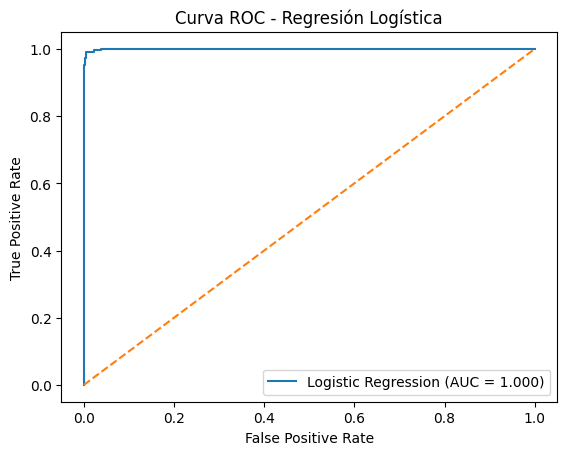

,LogisticRegression
Accuracy_train,0.9959
Accuracy_test,0.9943
Precision_train,0.9863
Precision_test,0.9784
Recall_train,0.9749
Recall_test,0.9700
F1_train,0.9805
F1_test,0.9741
ROC_AUC_train,0.9999
ROC_AUC_test,0.9996


In [135]:
modelo_logit, metricas_logit, confusion_matrix_logit = (
    regresion_logistica_clasificacion(
        X_train_,
        X_test_,
        y_train_,
        y_test_
    )
)

metricas_logit
